<a href="https://colab.research.google.com/github/ShmaliukhDA/MD_10_Home_tasks/blob/main/%22HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Аналітика Даних/Модуль 11/Data_csv/yulu_rental.csv')

In [ ]:

# Завантаження даних
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [ ]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

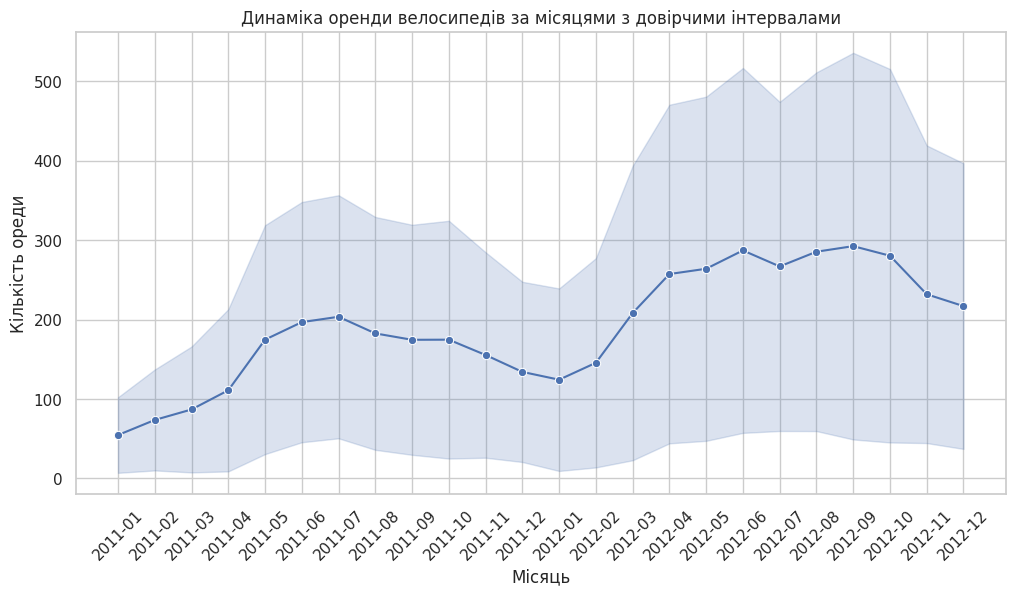

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(df, x='month_year',  y='count',errorbar='sd', marker ='o')
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість ореди')
plt.xticks(rotation=45);

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

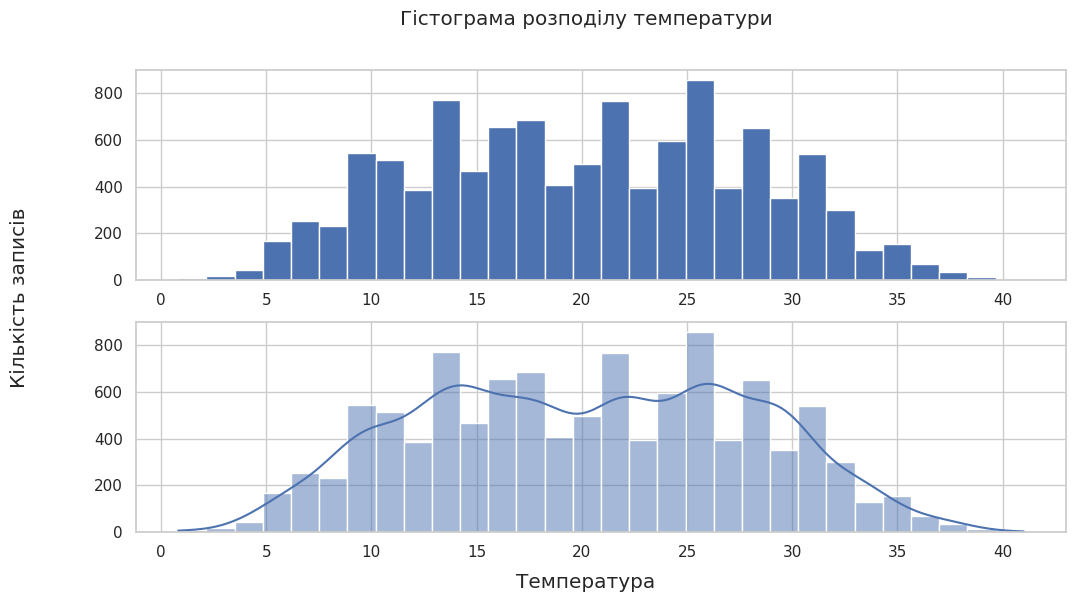

In [ ]:
fig = plt.figure(figsize=(12,6))
plt.suptitle('Гістограма розподілу температури')
fig.supxlabel('Температура')
fig.supylabel('Кількість записів')

plt.subplot(2,1,1)
df['temp'].plot.hist(bins=30)
plt.xlabel('')
plt.ylabel('')

plt.subplot(2,1,2)
sns.histplot(data=df,x='temp', bins=30, kde=True)
plt.xlabel('')
plt.ylabel('')
plt.show()


1.За своєю базовою структурою та розподілом даних гістограми є абсолютно однаковими й ідентичними — як згенерована засобами Pandas, так і побудована за допомогою Seaborn.

Основна відмінність полягає у додатковому функціоналі Seaborn: на нижньому графіку відображено криву ядерної оцінки щільності (KDE). Вона згладжує випадковий «шум» окремих стовпчиків і демонструє безперервну динаміку. Це дає більш наочне та притомне уявлення про те, як насправді змінюється температура та де знаходяться її основні піки.

2.Ця лінія називається KDE (ядерна оцінка щільності). Вона згладжує випадкові дрібні стрибки гістограми й малює плавну загальну картину розподілу. Це дозволяє побачити реальну форму даних та їхні головні піки (зони найбільшої концентрації), не прив'язуючись до розміру окремих стовпчиків».

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

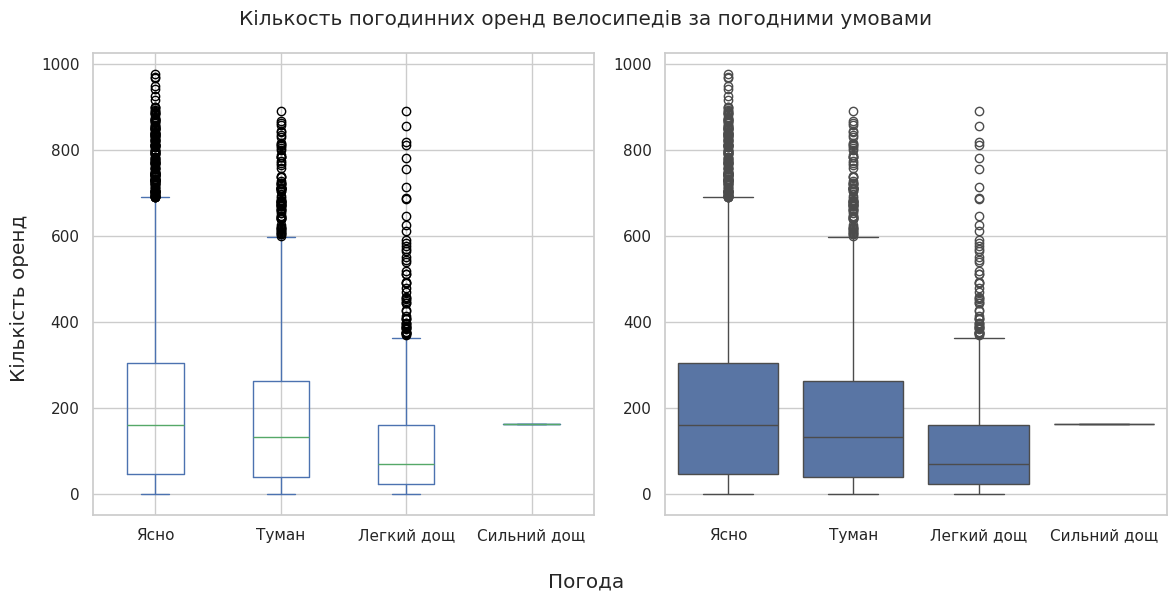

In [ ]:
fig = plt.figure(figsize=(12,6))
plt.suptitle('Кількость погодинних оренд велосипедів за погодними умовами')
fig.supxlabel('Погода')
fig.supylabel('Кількість оренд')

plt.subplot(1,2,1)
df[['count', 'weather']].plot.box(by='weather', ax=plt.gca())
plt.xticks(ticks=[1, 2, 3, 4], labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.title('')
plt.xlabel('')
plt.ylabel('')

plt.subplot(1,2,2)
sns.boxplot(data=df,x='weather',y='count')
plt.xlabel('')
plt.ylabel('')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.tight_layout()
plt.show()


З точки зору аналізу даних та інформативності між графіками немає жодної різниці — вони відображають абсолютно однакову статистику, медіани та викиди. Єдине відхилення полягає у візуальному оформленні: Seaborn будує більш сучасні зафарбовані «ящики», тоді як Pandas малює мінімалістичний графік контурами.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [ ]:
df.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,month_year
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,2011-01
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,2011-01


In [ ]:
correlation = df[['count','casual','registered', 'season', 'humidity', 'windspeed', 'temp','atemp']].corr()

In [ ]:
correlation

,count,casual,registered,season,humidity,windspeed,temp,atemp
count,1.000000,0.690414,0.970948,0.163439,-0.317371,0.101369,0.394454,0.389784
casual,0.690414,1.000000,0.497250,0.096758,-0.348187,0.092276,0.467097,0.462067
registered,0.970948,0.497250,1.000000,0.164011,-0.265458,0.091052,0.318571,0.314635
season,0.163439,0.096758,0.164011,1.000000,0.190610,-0.147121,0.258689,0.264744
humidity,-0.317371,-0.348187,-0.265458,0.190610,1.000000,-0.318607,-0.064949,-0.043536
windspeed,0.101369,0.092276,0.091052,-0.147121,-0.318607,1.000000,-0.017852,-0.057473
temp,0.394454,0.467097,0.318571,0.258689,-0.064949,-0.017852,1.000000,0.984948
atemp,0.389784,0.462067,0.314635,0.264744,-0.043536,-0.057473,0.984948,1.000000


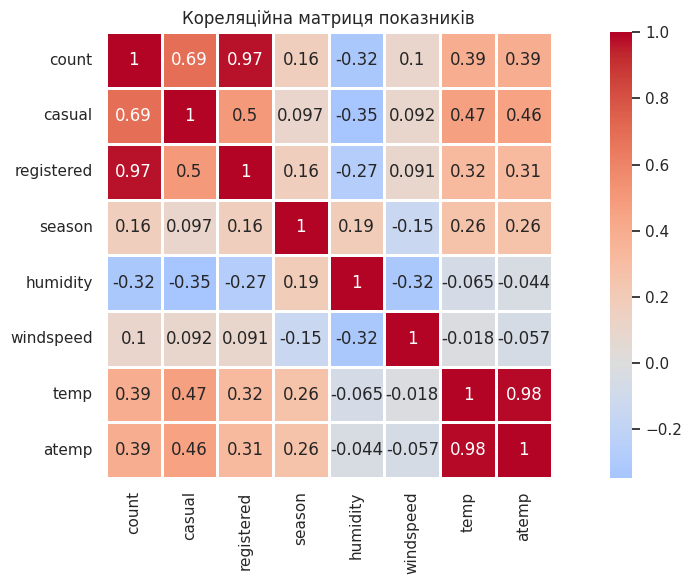

In [ ]:
plt.figure(figsize=(12, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1
            )

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()


**1. Які змінні найсильніше корелюють із загальною кількістю оренди?**

* **`registered`**: Має найвищу позитивну кореляцію.

**2. Яка кореляція між `temp` та `atemp` і чому?**

* **Кореляція**: Майже максимальна (близько 0,98).
* **Причина**: `temp` — це фактична температура, а `atemp` — відчутна. Оскільки відчутна є похідною від фактичної, їхні значення практично збігаються.

**3. Які змінні мають негативну кореляцію?**

* Вологість (`hum`)
* Швидкість вітру (`windspeed`)
* Погодні умови (`weathersit`)

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


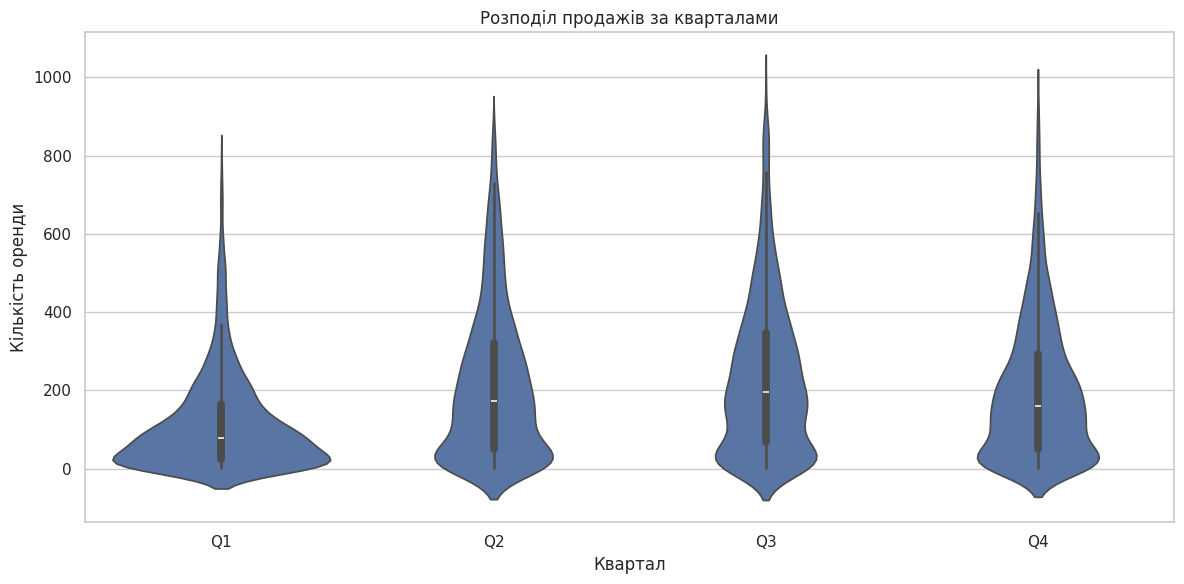

In [ ]:
plt.figure(figsize=(12,6))
sns.violinplot(data=df, x='season', y='count')

plt.xticks(ticks=[0, 1, 2, 3], labels=['Q1', 'Q2', 'Q3', 'Q4'])
plt.title('Розподіл продажів за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренди')
plt.tight_layout()
plt.show()

**1. Що показує «товщина» violin plot?**

* **Частоту значень**: Чим ширша ділянка, тим частіше трапляється саме така кількість орендованих велосипедів.

**2. В якому кварталі найбільша варіабельність оренди?**

* **У 3-му кварталі (Q3)**: Тут найдовший «хвіст» угору (понад 1000 орендувань) і найбільший розкид значень від мінімуму до максимуму.

**3. Яка перевага violin plot над звичайним box plot?**

* **Показує форму та піки**: Box plot показує лише коробку з прямокутників та ліній, а violin plot додатково демонструє всі «вигини» даних — де саме знаходиться найбільше скупчення результатів і чи є там кілька піків.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

In [ ]:
df.shape

(10886, 20)

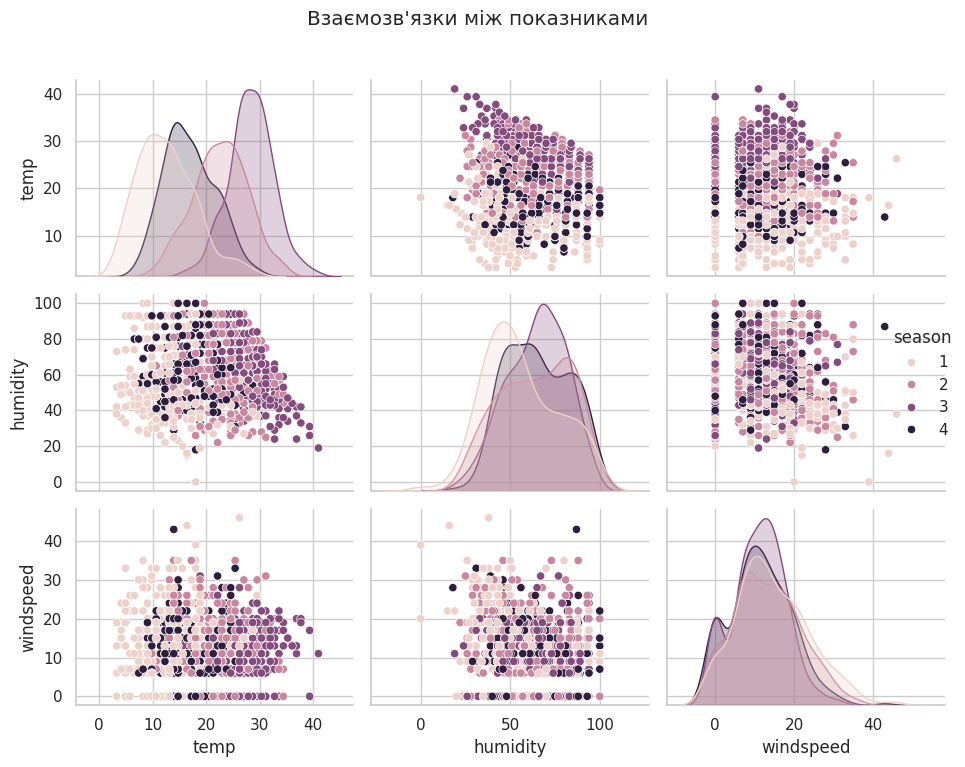

In [ ]:
df_sample= df[['temp', 'humidity', 'windspeed','season']].sample(1000)
sns.pairplot(df_sample, hue="season", height=2.5, aspect=1.2)
plt.suptitle('Взаємозв\'язки між показниками', y=1.02)
plt.tight_layout()
plt.show()



1. **Лінійний зв'язок**: Чіткого лінійного зв'язку між температурами, вологістю та швидкістю вітру **не виявлено** — точки на графіках розсіювання розміщені хаотично.
2. **Відмінність за сезонами**: Найбільше між сезонами відрізняється **температура** (`temp`), що чітко видно за розділеними піками розподілу. Натомість вологість та швидкість вітру залишаються практично однаковими впродовж усього року.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

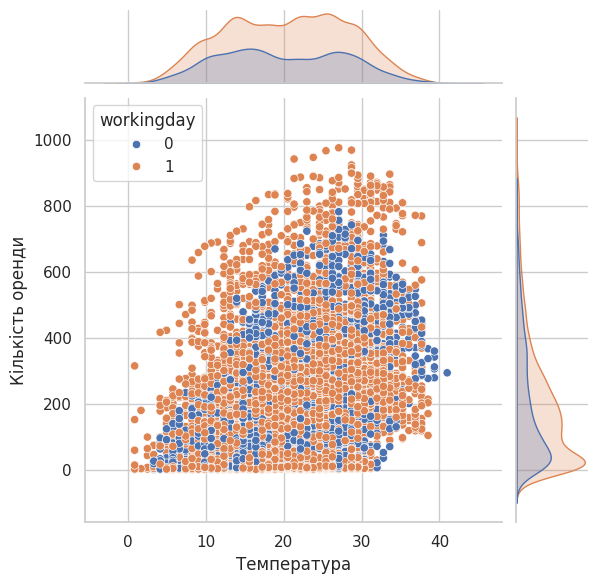

In [ ]:
sns.jointplot(data=df, x='temp', y='count', hue='workingday')
plt.xlabel('Температура')
plt.ylabel('Кількість оренди')

plt.show()


**1. Що показують графіки по краях?**

* **Верхній**: Розподіл (частоту) **температури**.
* **Правий**: Розподіл **кількості оренди**.

**2. Чи є різниця в поведінці в робочі та вихідні дні?**

У робочі дні оренда стабільно вища з максимальними піками (до 1000/год). У вихідні попит нижчий, а в холодні дні падає до мінімуму. Тепло суттєво піднімає попит у вихідні (до 600–800/год), але він все одно не перевищує показники робочих днів.